THE optimal thresholds (per eps):
  eps =  0.50  theta* = 0.5617  p = 0.5519  q = 0.4345
  eps =  0.70  theta* = 0.5857  p = 0.5675  q = 0.4073
  eps =  1.50  theta* = 0.6669  p = 0.6105  q = 0.3032
  eps =  1.70  theta* = 0.6850  p = 0.6175  q = 0.2793
  eps =  2.00  theta* = 0.7090  p = 0.6262  q = 0.2461
  eps =  2.50  theta* = 0.7451  p = 0.6364  q = 0.1970
  eps =  2.70  theta* = 0.7571  p = 0.6398  q = 0.1799
  eps =  3.00  theta* = 0.7722  p = 0.6447  q = 0.1570
  eps =  3.50  theta* = 0.7962  p = 0.6500  q = 0.1241
  eps =  3.70  theta* = 0.8053  p = 0.6513  q = 0.1127
  eps =  4.00  theta* = 0.8143  p = 0.6551  q = 0.0981
  eps =  4.50  theta* = 0.8323  p = 0.6571  q = 0.0769
  eps =  4.70  theta* = 0.8383  p = 0.6580  q = 0.0697
  eps =  5.00  theta* = 0.8474  p = 0.6586  q = 0.0601
  eps =  5.50  theta* = 0.8594  p = 0.6603  q = 0.0471
  eps =  5.70  theta* = 0.8624  p = 0.6622  q = 0.0428
  eps =  6.00  theta* = 0.8684  p = 0.6631  q = 0.0369
  eps =  6.50  theta* = 0.8774 

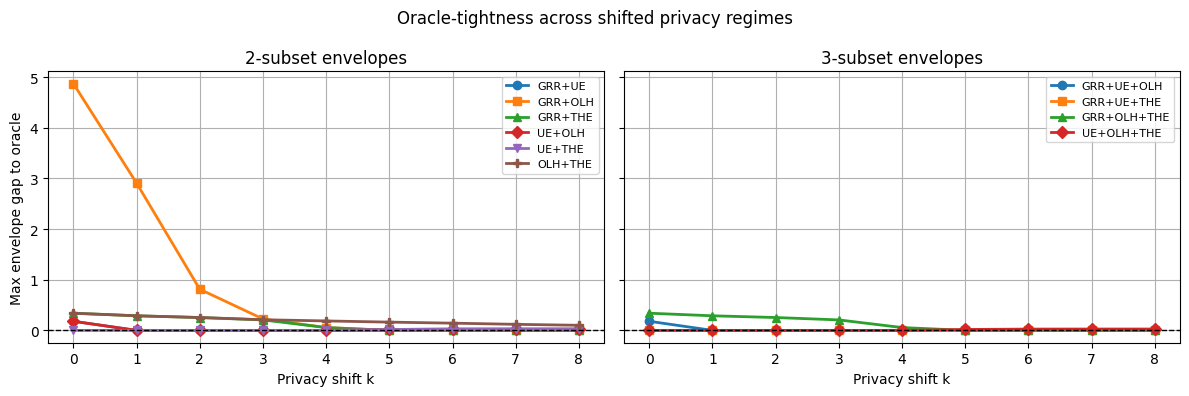

In [ ]:
import numpy as np
from itertools import combinations
from functools import lru_cache
import matplotlib.pyplot as plt
import pandas as pd
import os


# ============================================================
# 1. epsilon -> (p, q) parameters
# ============================================================

def grr_params(eps, d):
    p = np.exp(eps) / (np.exp(eps) + d - 1)
    q = 1.0 / (np.exp(eps) + d - 1)
    return p, q

def ue_params(eps):
    # OUE (optimized unary encoding)
    p = 0.5
    q = 1.0 / (np.exp(eps) + 1)
    return p, q

def olh_params(eps, g):
    p = np.exp(eps) / (np.exp(eps) + g - 1)
    q = 1.0 / (np.exp(eps) + g - 1)
    return p, q


# --- THE (Thresholding Histogram Encoding) ---------------------------

def _the_pq(eps, theta):
    """Marginal output probabilities for THE.

    User encodes value as one-hot B in {0,1}^d, adds N_i ~ Lap(2/eps)
    per coordinate, reports Y_i = 1[B_i + N_i > theta].
        p = P[1 + Lap(2/eps) > theta] = P[Lap > theta - 1]
        q = P[0 + Lap(2/eps) > theta] = P[Lap > theta]
    """
    b = 2.0 / float(eps)
    # q = P[Lap(b) > theta]
    if theta >= 0:
        q = 0.5 * np.exp(-theta / b)
    else:
        q = 1.0 - 0.5 * np.exp(theta / b)
    # p = P[Lap(b) > theta - 1]
    s = theta - 1.0
    if s >= 0:
        p = 0.5 * np.exp(-s / b)
    else:
        p = 1.0 - 0.5 * np.exp(s / b)
    return p, q

@lru_cache(maxsize=None)
def the_optimal_theta(eps, n_grid=400):
    """Variance-optimal threshold for THE at given eps.

    Minimizes the per-user variance proxy q(1-q)/(p-q)^2.
    Result is cached because eps_grid contains only a few unique values.
    """
    thetas = np.linspace(0.3, 1.5, n_grid)
    best_theta, best_var = 0.5, np.inf
    for theta in thetas:
        p, q = _the_pq(eps, theta)
        if p - q > 1e-12:
            v = q * (1.0 - q) / (p - q) ** 2
            if v < best_var:
                best_var = v
                best_theta = float(theta)
    return best_theta

def the_params(eps):
    """(p, q) for THE at variance-optimal theta."""
    theta = the_optimal_theta(float(eps))
    return _the_pq(eps, theta)


# ============================================================
# 2. Data generation
# ============================================================

def generate_data(n, d):
    return np.random.randint(0, d, size=n)


# ============================================================
# 3. Heterogeneous LDP perturbation (user side)
# ============================================================

def perturb_grr(data, epsilons, d):
    reports = []
    for x, eps in zip(data, epsilons):
        p, _ = grr_params(eps, d)
        if np.random.rand() < p:
            reports.append(x)
        else:
            others = list(range(d))
            others.remove(x)
            reports.append(np.random.choice(others))
    return reports

def _perturb_unary(data, epsilons, d, params_fn):
    """Shared unary-encoding perturbation: independent Bernoulli flips
    with rates (p, q) given by params_fn(eps)."""
    reports = []
    for x, eps in zip(data, epsilons):
        p, q = params_fn(eps)
        y = np.zeros(d)
        for j in range(d):
            prob = p if j == x else q
            y[j] = np.random.rand() < prob
        reports.append(y)
    return np.array(reports)

def perturb_ue(data, epsilons, d):
    return _perturb_unary(data, epsilons, d, ue_params)

def perturb_the(data, epsilons, d):
    """Faithful THE: one-hot encode, add Laplace noise per coordinate,
    threshold at theta*(eps). Distributionally identical to a Bernoulli
    perturbation with rates (p, q) = the_params(eps), but kept explicit
    for protocol fidelity / inspection."""
    reports = []
    for x, eps in zip(data, epsilons):
        b = 2.0 / float(eps)
        theta = the_optimal_theta(float(eps))
        true_bits = np.zeros(d)
        true_bits[x] = 1.0
        noisy = true_bits + np.random.laplace(0.0, b, size=d)
        reports.append((noisy > theta).astype(float))
    return np.array(reports)

def random_hash(g):
    a = np.random.randint(1, g)
    b = np.random.randint(0, g)
    return lambda x: (a * x + b) % g

def perturb_olh(data, epsilons, d, g):
    reports, hashes = [], []
    for x, eps in zip(data, epsilons):
        h = random_hash(g)
        p, _ = olh_params(eps, g)
        true_bucket = h(x)
        if np.random.rand() < p:
            y = true_bucket
        else:
            others = list(range(g))
            others.remove(true_bucket)
            y = np.random.choice(others)
        reports.append(y)
        hashes.append(h)
    return reports, hashes


# ============================================================
# 4. Heterogeneous unbiased estimators (server side)
# ============================================================

def estimate_grr(reports, epsilons, d):
    f_hat = np.zeros(d)
    for y, eps in zip(reports, epsilons):
        p, q = grr_params(eps, d)
        for v in range(d):
            if v == y:
                f_hat[v] += (1 - q) / (p - q)
            else:
                f_hat[v] -= q / (p - q)
    return f_hat / len(reports)

def _estimate_unary(reports, epsilons, params_fn):
    """Shared unary-encoding estimator: f_hat += (y - q) / (p - q).
    Used by UE and THE alike (THE's marginal output is Bernoulli)."""
    f_hat = np.zeros(reports.shape[1])
    for y, eps in zip(reports, epsilons):
        p, q = params_fn(eps)
        f_hat += (y - q) / (p - q)
    return f_hat / len(reports)

def estimate_ue(reports, epsilons):
    return _estimate_unary(reports, epsilons, ue_params)

def estimate_the(reports, epsilons):
    return _estimate_unary(reports, epsilons, the_params)

def estimate_olh(reports, epsilons, hashes, d, g):
    f_hat = np.zeros(d)
    for y, eps, h in zip(reports, epsilons, hashes):
        p, q = olh_params(eps, g)
        for v in range(d):
            if h(v) == y:
                f_hat[v] += (1 - q) / (p - q)
            else:
                f_hat[v] -= q / (p - q)
    return f_hat / len(reports)


# ============================================================
# 5. Run one mechanism
# ============================================================

def run_ldp(mechanism, data, epsilons, d, g=None):
    true_dist = np.bincount(data, minlength=d) / len(data)

    if mechanism == "GRR":
        reports = perturb_grr(data, epsilons, d)
        p_hat = estimate_grr(reports, epsilons, d)

    elif mechanism == "UE":
        reports = perturb_ue(data, epsilons, d)
        p_hat = estimate_ue(reports, epsilons)

    elif mechanism == "THE":
        reports = perturb_the(data, epsilons, d)
        p_hat = estimate_the(reports, epsilons)

    elif mechanism == "OLH":
        reports, hashes = perturb_olh(data, epsilons, d, g)
        p_hat = estimate_olh(reports, epsilons, hashes, d, g)

    else:
        raise ValueError(f"Unknown mechanism: {mechanism}")

    return np.linalg.norm(p_hat - true_dist, ord=2)


# ============================================================
# 6. Sample heterogeneous epsilons
# ============================================================

def sample_epsilons(eps_grid, n):
    return np.random.choice(eps_grid, size=n, replace=True)


# ============================================================
# 7. Lower envelope computation (subsets of any size)
# ============================================================

def compute_lower_envelope(mechanisms, eps_grid, n, d, N, g=None,
                           subset_sizes=(2, 3)):
    data = generate_data(n, d)

    R = {m: [] for m in mechanisms}
    mean_eps = []

    for _ in range(N):
        eps = sample_epsilons(eps_grid, n)
        mean_eps.append(np.mean(eps))
        for m in mechanisms:
            err = run_ldp(m, data, eps, d, g)
            R[m].append(err)

    oracle = [min(R[m][j] for m in mechanisms) for j in range(N)]

    # Mean risk of the lower envelope of every subset, for each size.
    subset_risk = {}
    for k_size in subset_sizes:
        for combo in combinations(mechanisms, k_size):
            subset_risk[combo] = np.mean(
                [min(R[m][j] for m in combo) for j in range(N)]
            )

    best_subset_per_size = {
        k_size: min(
            (combo for combo in subset_risk if len(combo) == k_size),
            key=subset_risk.get,
        )
        for k_size in subset_sizes
    }

    return R, oracle, mean_eps, best_subset_per_size


# ============================================================
# 8. Subset envelope gap + table construction
# ============================================================

def compute_subset_gap(R, oracle, mean_eps, subset_sizes=(2, 3)):
    """Per-trial envelope gap for every subset of each requested size.
    Returns {size: (gaps_dict, dataframe)}.
    """
    out = {}
    for k_size in subset_sizes:
        combos = list(combinations(R.keys(), k_size))
        gaps = {combo: [] for combo in combos}

        table = {"mean_eps": mean_eps}
        for combo in combos:
            key = "+".join(combo)
            table[key] = []
            for j in range(len(oracle)):
                env = min(R[m][j] for m in combo)
                gap = env - oracle[j]
                gaps[combo].append(gap)
                table[key].append(gap)

        out[k_size] = (gaps, pd.DataFrame(table))
    return out


# ============================================================
# 9. Main
# ============================================================

if __name__ == "__main__":
    mechanisms = ["GRR", "UE", "OLH", "THE"]
    subset_sizes = (2, 3)

    n = 1000
    d = 500
    g = 16
    N = 100

    # Show the THE thresholds chosen across all eps that will appear
    # in the sweep, so it's easy to sanity-check the optimization.
    all_eps = sorted({0.5 + k for k in range(9)} |
                     {0.7 + k for k in range(9)} |
                     {2 + k for k in range(9)})
    print("THE optimal thresholds (per eps):")
    for eps in all_eps:
        theta = the_optimal_theta(float(eps))
        p, q = _the_pq(eps, theta)
        print(f"  eps = {eps:5.2f}  theta* = {theta:.4f}  "
              f"p = {p:.4f}  q = {q:.4f}")

    # One CSV per subset size (column counts differ between sizes).
    csv_paths = {
        k_size: f"subset_gap_table_size{k_size}_n_{n}_d_{d}.csv"
        for k_size in subset_sizes
    }
    # Reset CSVs at the start of each run to avoid cross-run contamination.
    for path in csv_paths.values():
        if os.path.exists(path):
            os.remove(path)

    # Dynamic summary: one column per subset, regardless of size.
    summary = {"k": []}
    for k_size in subset_sizes:
        for combo in combinations(mechanisms, k_size):
            summary["+".join(combo)] = []

    for k in range(9):
        eps_grid = [0.5 + k, 0.7 + k, 2 + k]

        R, oracle, mean_eps, best_subsets = compute_lower_envelope(
            mechanisms, eps_grid, n, d, N, g, subset_sizes=subset_sizes
        )

        for size, combo in best_subsets.items():
            print(f"k={k}  best {size}-subset: {'+'.join(combo)}")

        gap_results = compute_subset_gap(R, oracle, mean_eps, subset_sizes)

        for size, (gaps, df) in gap_results.items():
            print(f"\n=== Envelope Gap Table (size {size}, k={k}) ===")
            print(df)

            path = csv_paths[size]
            df.to_csv(
                path,
                mode="a",
                header=not os.path.exists(path),
                index=False,
            )

        # Worst-case gap per subset for the summary plot.
        summary["k"].append(k)
        for size, (_, df) in gap_results.items():
            for combo in combinations(mechanisms, size):
                key = "+".join(combo)
                summary[key].append(df[key].max())

    # ============================================================
    # Plot: max envelope gap vs privacy shift k, one panel per size
    # ============================================================
    fig, axes = plt.subplots(
        1, len(subset_sizes),
        figsize=(6 * len(subset_sizes), 4),
        sharey=True,
    )
    if len(subset_sizes) == 1:
        axes = [axes]

    markers = ["o", "s", "^", "D", "v", "P", "X", "*", "h", "<"]

    for ax, size in zip(axes, subset_sizes):
        for i, combo in enumerate(combinations(mechanisms, size)):
            key = "+".join(combo)
            ax.plot(
                summary["k"], summary[key],
                marker=markers[i % len(markers)],
                linewidth=2, label=key,
            )
        ax.axhline(0, color="black", linestyle="--", linewidth=1)
        ax.set_xlabel("Privacy shift k")
        ax.set_title(f"{size}-subset envelopes")
        ax.grid(True)
        ax.legend(fontsize=8)
    axes[0].set_ylabel("Max envelope gap to oracle")

    fig.suptitle("Oracle-tightness across shifted privacy regimes")
    plt.tight_layout()
    plt.show()

In [ ]:
"""
Privacy Budget vs Envelope Gap Plotter
Reads a CSV file and plots curves for every method/subset column it finds
(any column besides `mean_eps`). Saves the figure as PDF and PNG next to the CSV.

Usage:
    python privacy_budget_plotter.py path/to/data.csv
    python privacy_budget_plotter.py          # will prompt for path
"""

import sys

import matplotlib
matplotlib.use("Agg")           # headless – no display needed
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import pandas as pd
from matplotlib.ticker import MaxNLocator


# ── Style assignment ─────────────────────────────────────────────────────────
# Backward-compatible exact colors for original 3-mechanism pair names so
# regenerated plots from old CSVs look identical to the previous version.
LEGACY_COLORS = {
    "GRR+UE":  "#1f77b4",   # blue
    "GRR+OLH": "#2ca02c",   # green
    "UE+OLH":  "#ff7f0e",   # orange
}

# Fallback palette for any other column. tab10 first, then tab20 for overflow.
# Stored as hex strings so set-membership comparisons against LEGACY_COLORS work
# (matplotlib colormaps return RGB tuples by default).
import matplotlib.colors as _mcolors
FALLBACK_PALETTE = [
    _mcolors.to_hex(c) for c in
    list(plt.get_cmap("tab10").colors) + list(plt.get_cmap("tab20").colors)
]

MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*", "h", "<", ">"]
LINESTYLES = ["-", "--", "-.", ":"]   # cycled every 4 series


# ── Global typography ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "DejaVu Sans",
    "axes.titlesize":     28,
    "axes.titleweight":   "bold",
    "axes.labelsize":     28,
    "axes.labelweight":   "bold",
    "xtick.labelsize":    32,
    "ytick.labelsize":    32,
    "legend.fontsize":    28,
    "legend.title_fontsize": 26,
    "grid.alpha":         0.35,
    "grid.linestyle":     "--",
})

# ── Inset typography ─────────────────────────────────────────────────────────
INSET_TITLE_SIZE  = 34
INSET_LABEL_SIZE  = 34
INSET_TICK_SIZE   = 30
N_XTICKS = 4          # target number of x-axis ticks; None = matplotlib default
LEGEND_MAX_COLS = 2   # max series per legend row; more series wrap to new row(s)

# ── Inset range (hardcoded) ──────────────────────────────────────────────────
# Set INSET_XLIM to a (lo, hi) tuple to fix the magnified x-range, or None to
# auto-pick the middle 30% of the data. Same convention for INSET_YLIM, where
# None auto-fits y to whatever data falls inside the chosen x-range.
INSET_XLIM = (5, 7.5)
INSET_YLIM = None


def pick_csv() -> str:
    """Return the CSV path: first CLI argument, or ask interactively.
    Filters out Jupyter-injected flags like -f ~/.local/share/jupyter/...
    """
    user_args = [a for a in sys.argv[1:]
                 if not a.startswith("-") and "jupyter" not in a.lower()]
    if user_args:
        return user_args[0]
    path = input("Enter path to CSV file: ").strip().strip("'\"")
    return path


def load_data(path: str):
    """Read CSV; return (dataframe, list of series-column names).
    Series columns are everything except `mean_eps`."""
    df = pd.read_csv(path)
    if "mean_eps" not in df.columns:
        raise ValueError("CSV must contain a 'mean_eps' column.")
    series_cols = [c for c in df.columns if c != "mean_eps"]
    if not series_cols:
        raise ValueError("CSV has no series columns besides 'mean_eps'.")
    return df, series_cols


def assign_styles(series_cols):
    """Give each series a (color, marker, linestyle, linewidth).
    Legacy pair names keep their original colors for backward compatibility.
    """
    legacy_color_set = set(LEGACY_COLORS.values())
    fallback_iter = iter(c for c in FALLBACK_PALETTE
                         if c not in legacy_color_set)

    styles = {}
    for i, name in enumerate(series_cols):
        color = LEGACY_COLORS.get(name) or next(fallback_iter)
        marker = MARKERS[i % len(MARKERS)]
        linestyle = LINESTYLES[(i // 4) % len(LINESTYLES)]
        # Heavier line on the first series acts as a visual anchor.
        linewidth = 3.0 if i == 0 else 2.0
        styles[name] = (color, marker, linestyle, linewidth)
    return styles


def plot_curves(ax, df, series_cols, styles, markersize=7):
    x = df["mean_eps"]
    for name in series_cols:
        color, marker, ls, lw = styles[name]
        ax.plot(
            x, df[name],
            marker=marker, linestyle=ls, linewidth=lw, markersize=markersize,
            label=name.replace("+", " + "),
            color=color, zorder=3,
        )


def add_grid(ax) -> None:
    ax.grid(True, which="major")
    ax.grid(True, which="minor", alpha=0.2)
    ax.minorticks_on()


def adaptive_inset_xrange(df):
    """Pick the middle ~30% of `mean_eps` for the zoomed inset.
    Returns (xlo, xhi), or None if too few unique points to be useful."""
    eps_sorted = df["mean_eps"].sort_values().to_numpy()
    if len(eps_sorted) < 6:
        return None
    lo_q, hi_q = 0.35, 0.65
    xlo = eps_sorted[int(len(eps_sorted) * lo_q)]
    xhi = eps_sorted[int(len(eps_sorted) * hi_q) - 1]
    if xhi - xlo < 1e-6:
        return None
    return float(xlo), float(xhi)


def build_figure(df, series_cols):
    styles = assign_styles(series_cols)
    n_series = len(series_cols)

    # Cap legend columns so it wraps onto extra rows instead of running
    # past the axes width. Lower LEGEND_MAX_COLS to force more wrapping
    # (e.g. 2 -> at most 2 series per row), raise it to pack more per row.
    legend_ncol = min(n_series, LEGEND_MAX_COLS)
    n_legend_rows = -(-n_series // legend_ncol)  # ceil division

    # More legend rows need more reserved space above the axes.
    top_margin = max(0.65, 0.90 - 0.09 * (n_legend_rows - 1))

    fig, ax_main = plt.subplots(figsize=(13, 9))
    fig.subplots_adjust(left=0.10, right=0.97, top=top_margin, bottom=0.12)

    # ── Main plot ─────────────────────────────────────────────────────────────
    plot_curves(ax_main, df, series_cols, styles, markersize=10)
    ax_main.set_xlabel("Mean Privacy Budget  \u03b5\u0305")
    ax_main.set_ylabel("Max Envelope Gap to Oracle")
    if N_XTICKS is not None:
        ax_main.xaxis.set_major_locator(MaxNLocator(nbins=N_XTICKS))

    # Legend on top, no bounding box. mode="expand" stretches each row to
    # exactly fill the axes width (bbox_to_anchor width = 1.0 in axes
    # coords), so it wraps onto n_legend_rows rows but never spills past
    # the left/right edges of the plot.
    ax_main.legend(
        loc="lower left",
        bbox_to_anchor=(0.0, 1.02, 1.0, 0.2),
        ncol=legend_ncol,
        mode="expand",
        frameon=False,
        borderaxespad=0.0,
    )
    add_grid(ax_main)

    # ── Inset (hardcoded range, with adaptive fallback when constants are None)
    inset_range = INSET_XLIM if INSET_XLIM is not None else adaptive_inset_xrange(df)
    if inset_range is not None:
        ax_ins = fig.add_axes([0.57, 0.42, 0.38, 0.36])
        plot_curves(ax_ins, df, series_cols, styles, markersize=6)

        xlo, xhi = inset_range
        ax_ins.set_xlim(xlo, xhi)

        if INSET_YLIM is not None:
            ax_ins.set_ylim(*INSET_YLIM)
        else:
            mask = (df["mean_eps"] >= xlo) & (df["mean_eps"] <= xhi)
            if mask.any():
                zoom_vals = pd.concat([df.loc[mask, c] for c in series_cols])
                ylo, yhi = zoom_vals.min(), zoom_vals.max()
                margin = (yhi - ylo) * 0.15 or 0.05
                ax_ins.set_ylim(ylo - margin, yhi + margin)


        ax_ins.tick_params(labelsize=INSET_TICK_SIZE)
        add_grid(ax_ins)

    return fig


def main() -> None:
    csv_path = pick_csv()
    if not csv_path:
        print("No file provided. Exiting.")
        sys.exit(0)

    df, series_cols = load_data(csv_path)
    print(f"Detected {len(series_cols)} series: {', '.join(series_cols)}")

    fig = build_figure(df, series_cols)

    base = csv_path.rsplit(".", 1)[0]

    # Save PDF
    out_pdf = base + "_privacy_budget_plot.pdf"
    with PdfPages(out_pdf) as pdf:
        pdf.savefig(fig, bbox_inches="tight")
        d = pdf.infodict()
        d["Title"]   = "Oracle-Tightness Across Mean Privacy Budget"
        d["Subject"] = "Privacy Budget vs Envelope Gap"

    # Save PNG (for quick viewing)
    out_png = base + "_privacy_budget_plot.png"
    fig.savefig(out_png, dpi=150, bbox_inches="tight")

    print(f"PDF saved -> {out_pdf}")
    print(f"PNG saved -> {out_png}")


if __name__ == "__main__":
    main()

Enter path to CSV file: /content/subset_gap_table_size3_n_1000_d_500.csv
Detected 4 series: GRR+UE+OLH, GRR+UE+THE, GRR+OLH+THE, UE+OLH+THE
PDF saved -> /content/subset_gap_table_size3_n_1000_d_500_privacy_budget_plot.pdf
PNG saved -> /content/subset_gap_table_size3_n_1000_d_500_privacy_budget_plot.png
